- Based on MVC (Model View Controller)
- Model: Manages data and business logic
- View: Handles layout and display
- Controller: Routes commands to the model and displays

When a user is requesting specific page from the server, it sends all requests to controller. It is responsible for handling all the requests from client. It acts as middlemen between model and view. Whevener it receives requests, it asks model for the data. the model is responsible for handling all the data model from the request. Interacts with data. Controller then needs to interact with the view and update it. View has a template which dynamically renders after receiving data. It gets the presentation and sends back to controller. Controller then sends back to server.
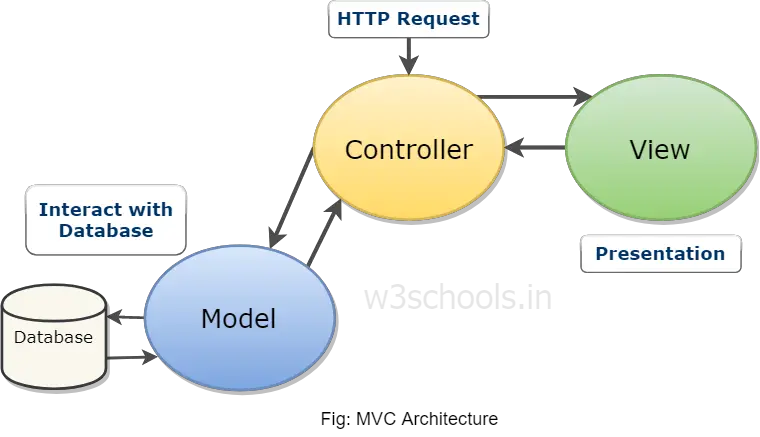

`RE`presentational `S`tate `T`ransfer
- Defines a pattern for client and server communications over a network
- A system is RESTful if it follows below architectural constraints
    - Client and Server: Independent. Client only displays UI and server only serves handles
    - Stateless: No memory of previous requests (client context) on server, each request must be self contained
    - Cacheable: Allows clients or intermediaries to store and reuse responses
    - Layered Structure: Architecture has multiple layers (load balancers, gateway, caching layers). Client don't need to know the internal structure
    - Code on demand: Server can send executable code that clients can run.
- Listen for HTTP methods to know which action to perform GET, PUT, POST etc., on web service resources
- Resource is data available in web service
- Web service is a software program that responds to requests over web (REST API, SOAP calls)
- A server is where the web service lives or runs

- ``Requests`` library is de facto standard for making http requests in python.
- Requests library cannot make async HTTP requests. For making asyc requests, use `AIOHTTP` or `HTTPX` library. The latter one is more compatible with requests library.
- Response 
    - response instance can be used to include in conditional statements as it evaluates to true if the status_code is below 400 (ie. b/w 200 and 399)
    - invoking _raise_for_status() will throw errors if the status codes are b/w 400 & 600
    - .content() gives us access to raw bytes of the response payload

In [13]:
import requests
# get a todo item from the JSONPlaceholder API
api_url = 'https://jsonplaceholder.typicode.com/todos'
get_response = requests.get(api_url+'/1')
if get_response.status_code == 200:
    get_todo_item = get_response.json()
    print(f"Todo ID: {get_todo_item['id']}")
    print(f"Title: {get_todo_item['title']}")
    print(f"Completed: {get_todo_item['completed']}")
print(get_response.headers)

Todo ID: 1
Title: delectus aut autem
Completed: False
{'Date': 'Tue, 24 Jun 2025 03:01:01 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Server': 'cloudflare', 'Report-To': '{"group":"heroku-nel","max_age":3600,"endpoints":[{"url":"https://nel.heroku.com/reports?ts=1745379009&sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d&s=3cFKQN67VMfzIaOfHym0Tu2vzwmCME8xKJTuyScmoxU%3D"}]}', 'Reporting-Endpoints': 'heroku-nel=https://nel.heroku.com/reports?ts=1745379009&sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d&s=3cFKQN67VMfzIaOfHym0Tu2vzwmCME8xKJTuyScmoxU%3D', 'Nel': '{"report_to":"heroku-nel","max_age":3600,"success_fraction":0.005,"failure_fraction":0.05,"response_headers":["Via"]}', 'X-Powered-By': 'Express', 'X-Ratelimit-Limit': '1000', 'X-Ratelimit-Remaining': '999', 'X-Ratelimit-Reset': '1745379021', 'Vary': 'Origin, Accept-Encoding', 'Access-Control-Allow-Credentials': 'true', 'Cache-Control': 'max-age=43200', 'Pragma': 'no-cache'

In [ ]:
todo_item = {
    'userId': 1,
    'title': 'Learn Python',
    'completed': False}
post_response = requests.post(api_url, json=todo_item)
if post_response.status_code == 201:
    created_todo = post_response.json()
    print(f"Created Todo ID: {created_todo['id']}")
    print(f"Title: {created_todo['title']}")
    print(f"Completed: {created_todo['completed']}")
print(post_response.headers)

{'userId': 1, 'title': 'Learn Python', 'completed': False, 'id': 201}
Created Todo ID: 201
Title: Learn Python
Completed: False
{'Date': 'Tue, 24 Jun 2025 03:55:40 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Content-Length': '79', 'Connection': 'keep-alive', 'Access-Control-Allow-Credentials': 'true', 'Access-Control-Expose-Headers': 'Location', 'Cache-Control': 'no-cache', 'Etag': 'W/"4f-bpTPQXju2l8jlDLaVUoRq4kzYj0"', 'Expires': '-1', 'Location': 'https://jsonplaceholder.typicode.com/todos/201', 'Nel': '{"report_to":"heroku-nel","response_headers":["Via"],"max_age":3600,"success_fraction":0.01,"failure_fraction":0.1}', 'Pragma': 'no-cache', 'Report-To': '{"group":"heroku-nel","endpoints":[{"url":"https://nel.heroku.com/reports?s=3ykf0BxxNg2z7EkVJF2LhPCPqJcX2Ia0XaFWERt7QZw%3D\\u0026sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d\\u0026ts=1750737340"}],"max_age":3600}', 'Reporting-Endpoints': 'heroku-nel="https://nel.heroku.com/reports?s=3ykf0BxxNg2z7EkVJF2LhPCPqJcX2Ia0XaFWERt7QZ

In [25]:
todo = requests.get('https://jsonplaceholder.typicode.com/todos/1').json()
print(todo)
todo['completed'] = True
# print(api_url+'/'+str(created_todo['id']))
put_response = requests.put(api_url+'/'+str(todo['id']), json=todo)
if put_response.status_code == 200:
    updated_todo = put_response.json()
    print(f"Updated Todo ID: {updated_todo['id']}")
    print(f"Title: {updated_todo['title']}")
    print(f"Completed: {updated_todo['completed']}")
print(put_response.headers)

{'userId': 1, 'id': 1, 'title': 'delectus aut autem', 'completed': False}
Updated Todo ID: 1
Title: delectus aut autem
Completed: True
{'Date': 'Tue, 24 Jun 2025 03:58:33 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Access-Control-Allow-Credentials': 'true', 'Cache-Control': 'no-cache', 'Etag': 'W/"52-BMMBWCgK7f7gWAWzfx3GjQfqsQc"', 'Expires': '-1', 'Nel': '{"report_to":"heroku-nel","response_headers":["Via"],"max_age":3600,"success_fraction":0.01,"failure_fraction":0.1}', 'Pragma': 'no-cache', 'Report-To': '{"group":"heroku-nel","endpoints":[{"url":"https://nel.heroku.com/reports?s=%2FsmnONYyOalViouglStktrFxqP1gDzz3039o6iZ7vHw%3D\\u0026sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d\\u0026ts=1750737513"}],"max_age":3600}', 'Reporting-Endpoints': 'heroku-nel="https://nel.heroku.com/reports?s=%2FsmnONYyOalViouglStktrFxqP1gDzz3039o6iZ7vHw%3D&sid=e11707d5-02a7-43ef-b45e-2cf4d2036f7d&ts=1750737513"', 'Server': 'cloudflare', '

![API versioning.png](<attachment:API versioning.png>)
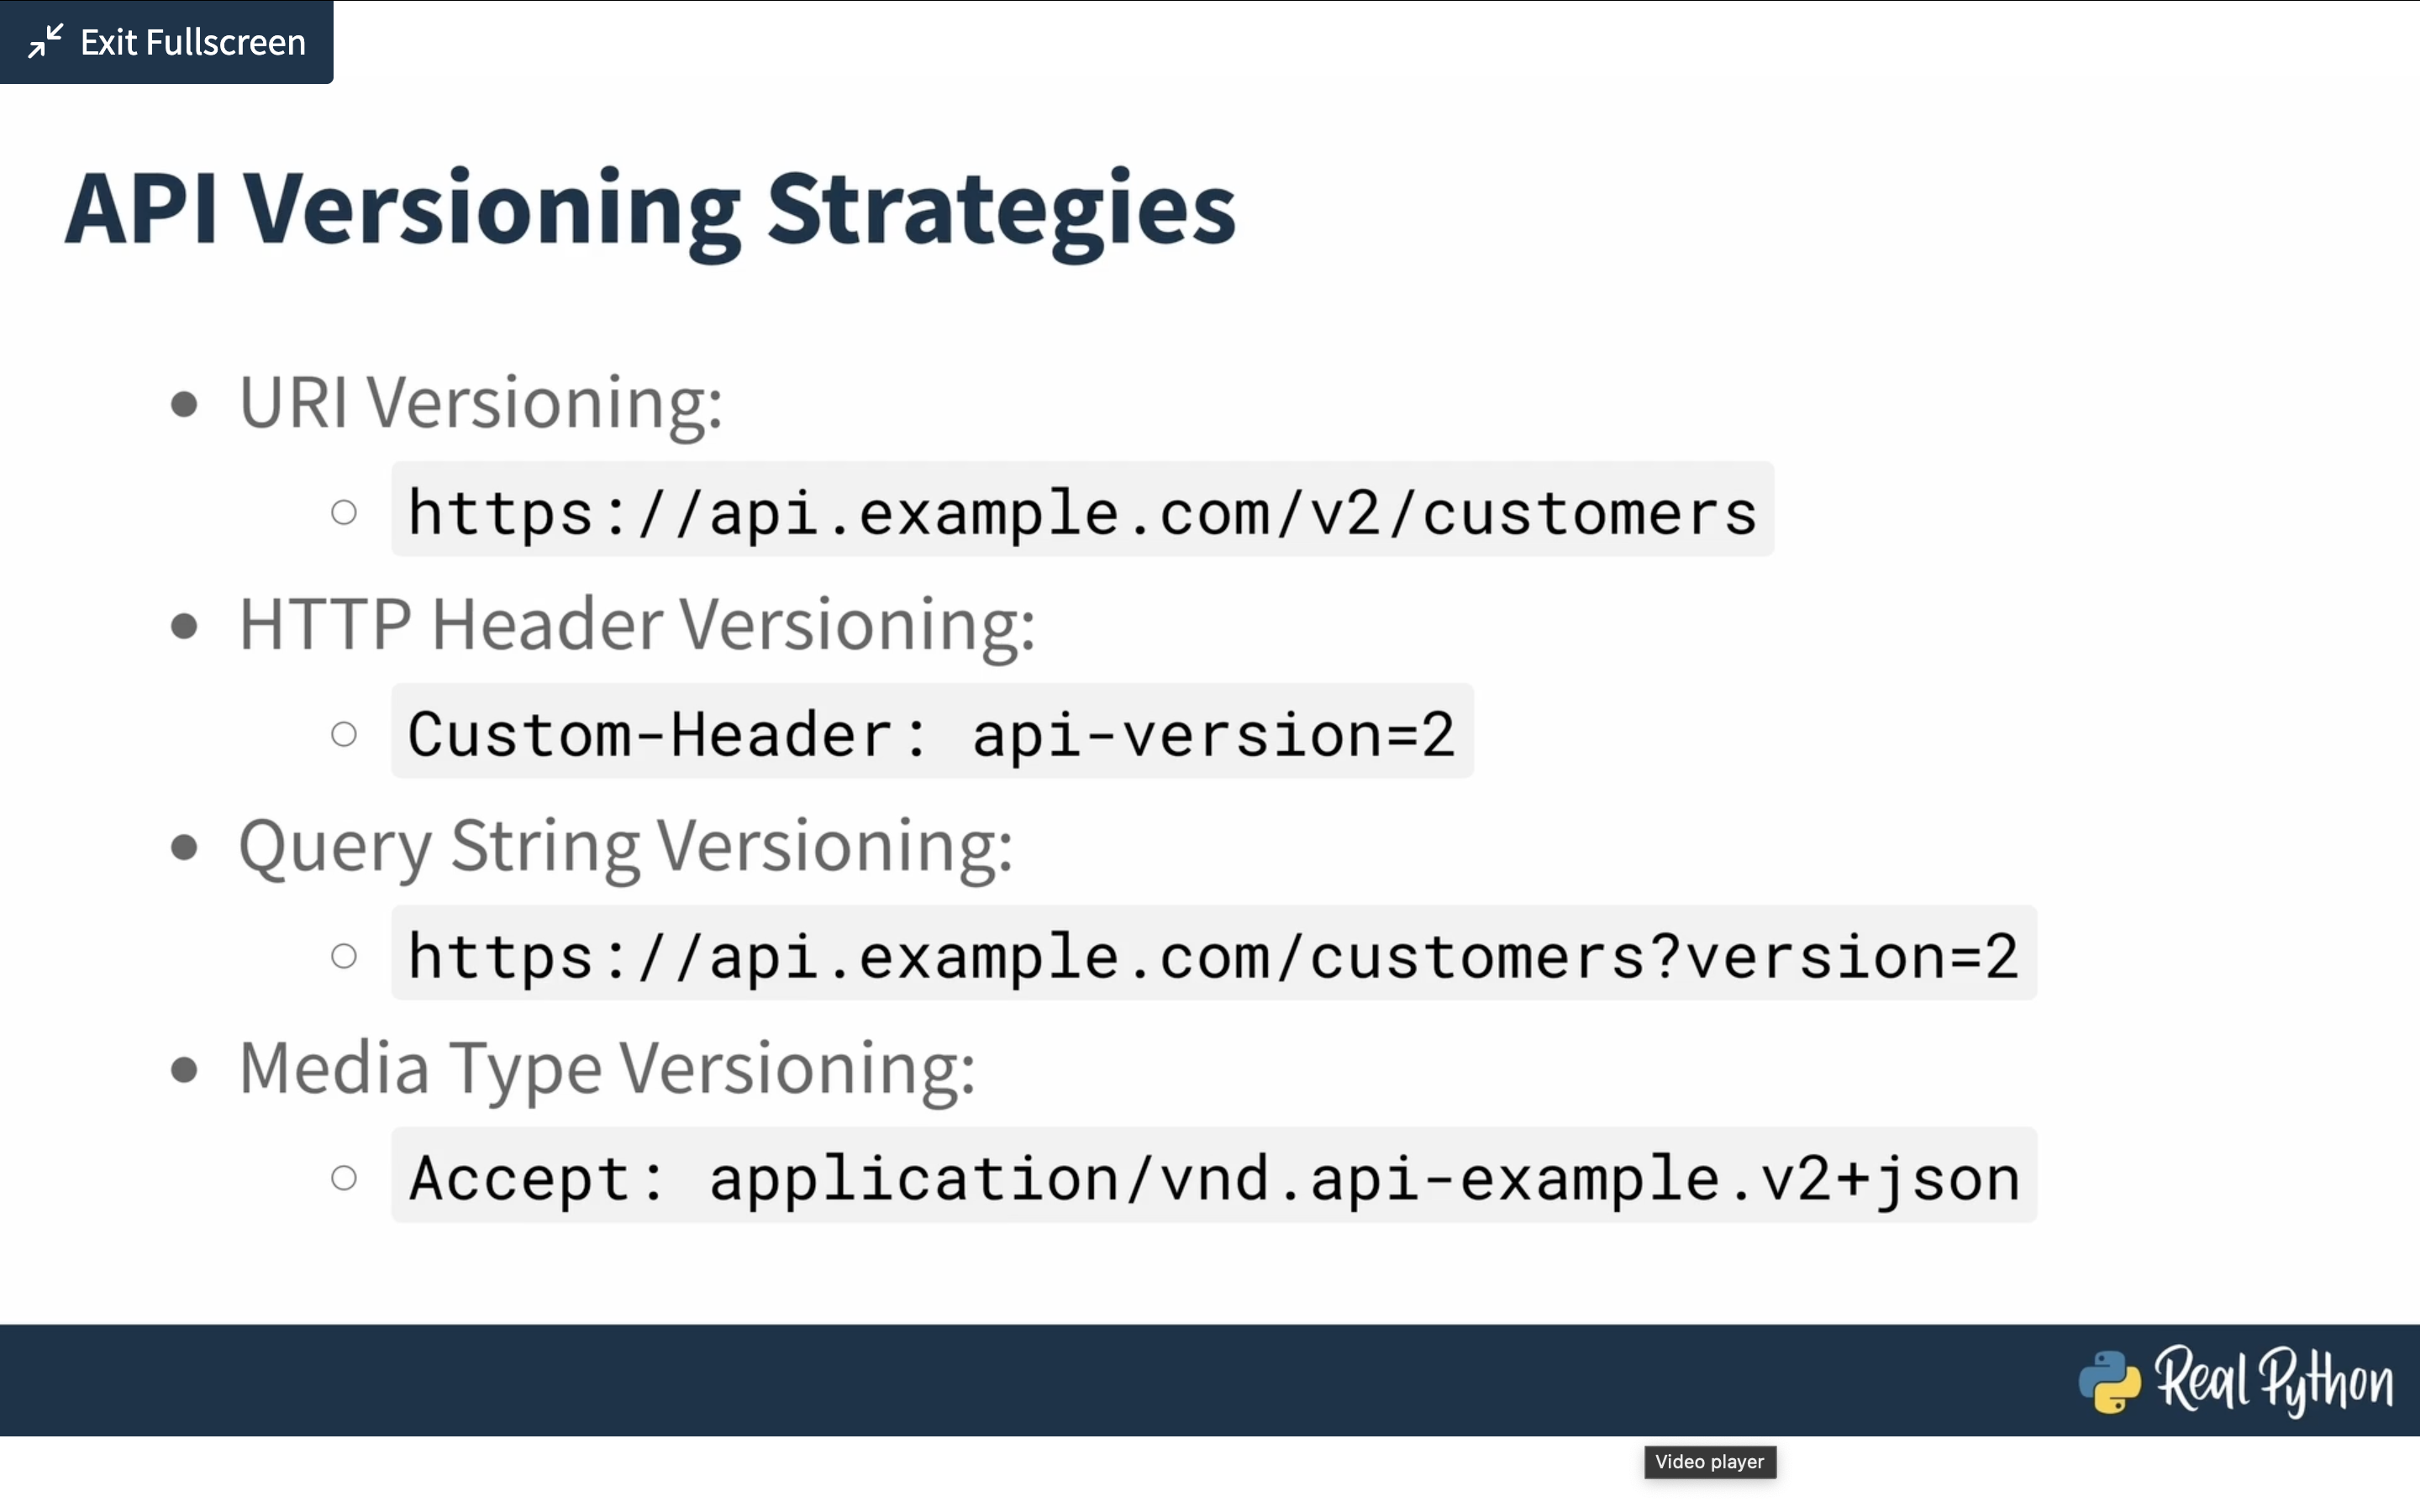

| Code Range | Category |
| ---------- | -------- |
| 2xx | Successful operation |
| 3xx | Redirection |
| 4xx | Client error | 
| 5xx | Server error |

| Type | Content type (HTTP Header)|
| ---------- | -------- |
| JSON | application/json (type/subtype) |
| XML | application/xml |